# Mini-project: Applying supervised learning to predict student dropout

**Welcome to your Mini-project: Applying supervised learning to predict student dropout rate**

In this project, we will examine student data and use supervised learning techniques to predict whether a student will drop out. In the education sector, retaining students is vital for the institution's financial stability and for students’ academic success and personal development. A high dropout rate can lead to significant revenue loss, diminished institutional reputation, and lower overall student satisfaction.

You will work with the data in three distinct stages:

1.  Applicant and course information
2.  Student and engagement data
3.  Academic performance data

These stages reflect Study Group’s real-world data journey and how student information has progressed and become available. Additionally, this approach enables you, through data exploration, to support Study Group in better understanding and identifying key metrics to monitor. This approach will also assist you in determining at which stage of the student journey interventions would be most effective.

Please set aside approximately **12 hours** to complete the mini-project.

## Business context
Study Group specialises in providing educational services and resources to students and professionals across various fields. The company's primary focus is on enhancing learning experiences through a range of services, including online courses, tutoring, and educational consulting. By leveraging cutting-edge technology and a team of experienced educators, Study Group aims to bridge the gap between traditional learning methods and the evolving needs of today's learners.

Study Group serves its university partners by establishing strategic partnerships to enhance the universities’ global reach and diversity. It supports the universities in their efforts to attract international students, thereby enriching the cultural and academic landscape of their campuses. It works closely with university faculty and staff to ensure that the universities are prepared and equipped to welcome and support a growing international student body. Its partnership with universities also offers international students a seamless transition into their chosen academic environment.

Study Group runs several International Study Centres across the UK and Dublin in partnership with universities with the aim of preparing a pipeline of talented international students from diverse backgrounds for degree study. These centres help international students adapt to the academic, cultural, and social aspects of studying abroad. This is achieved by improving conversational and subject-specific language skills and academic readiness before students progress to a full degree programme at university.

Through its comprehensive suite of services, it supports learners and universities at every stage of their educational journey, from high school to postgraduate studies. Its approach is tailored to meet the unique needs of each learner, offering personalised learning paths and flexible scheduling options to accommodate various learning styles and commitments.

Study Group's services are designed to be accessible and affordable, making quality education a reality for many individuals. By focusing on the integration of technology and personalised learning, the company aims to empower learners to achieve their full potential and succeed in their academic and professional pursuits. Study Group is at the forefront of transforming how people learn and grow through its dedication to innovation and excellence.

Study Group has provided you with 3 data sets.


## Objective
By the end of this mini-project, you will have developed the skills and knowledge to apply advanced machine learning techniques to create a predictive model for student dropout. This project will involve comprehensive data exploration, preprocessing, and feature engineering to ensure high-quality input for the models. You will employ and compare multiple predictive algorithms, such as XGBoost, and a neural network-based model, to determine the most effective model for predicting student dropout.

In the Notebook, you will:
- explore the data sets, taking a phased approach
- preprocess the data and conduct feature engineering
- predict the dropout rate using XGBoost, and a neural network-based model.

You will also write a report summarising the results of your findings and recommendations.

## Assessment criteria
By completing this project, you’ll be able to provide evidence that you can:

- develop accurate predictions across diverse organisational scenarios by building and testing advanced ML models
- inform data-driven decision-making with advanced machine learning algorithms and models
- propose and present effective solutions to organisational problems using data preprocessing, model selection, and insightful analysis techniques.

# Stage 1 data

In [ ]:
# File URL
file_url = "https://drive.google.com/uc?id=1pA8DDYmQuaLyxADCOZe1QaSQwF16q1J6"

**Stage 1: Pre-processing instructions**
- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with > 50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.

# Import Necessary Libraries

In [ ]:
# Importn the required libraries
import pandas as pd
import numpy as np

# Load and view data set

In [ ]:
# Load data set
df_stage1 = pd.read_csv(file_url)
df_stage1.head()

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen


In [ ]:
# Check for metadata
df_stage1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CentreName             25059 non-null  object
 1   LearnerCode            25059 non-null  int64 
 2   BookingType            25059 non-null  object
 3   LeadSource             25059 non-null  object
 4   DiscountType           7595 non-null   object
 5   DateofBirth            25059 non-null  object
 6   Gender                 25059 non-null  object
 7   Nationality            25059 non-null  object
 8   HomeState              8925 non-null   object
 9   HomeCity               21611 non-null  object
 10  CourseLevel            25059 non-null  object
 11  CourseName             25059 non-null  object
 12  IsFirstIntake          25059 non-null  bool  
 13  CompletedCourse        25059 non-null  object
 14  ProgressionDegree      24184 non-null  object
 15  ProgressionUniversi

In [ ]:
# Check for null values
df_stage1.isnull().sum()


,0
CentreName,0
LearnerCode,0
BookingType,0
LeadSource,0
DiscountType,17464
DateofBirth,0
Gender,0
Nationality,0
HomeState,16134
HomeCity,3448


# Perform Preprocessing

In [ ]:
# Removing unuseful columns(LearnerCode)
if 'LearnerCode' in df_stage1.columns:
    df_stage1 = df_stage1.drop('LearnerCode', axis=1)
    print("Removed 'LearnerCode' column.")
else:
    print("'LearnerCode' column not found, likely already removed.")
df_stage1

Removed 'LearnerCode' column.


,CentreName,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25054,ISC_Teesside,Agent,Standard Agent Booking,Bursary,3/6/1992,Male,Myanmarian,Taunggyi,Shan State,Pre-Masters,Accelerated Pre-Masters Programme Computing; E...,False,Yes,MSc Sustainable Engineering Systems,Teesside University
25055,ISC_Teesside,Agent,Standard Agent Booking,NaN,18/03/1995,Male,Kenyan,NaN,Nairobi,Pre-Masters,Accelerated Pre-Masters Programme Computing; E...,False,Yes,MSc Data Science (with Advanced Practice),Teesside University
25056,ISC_Teesside,Agent,Standard Agent Booking,Bursary,21/08/1997,Female,Malaysian,Johor,Skudai,Pre-Masters,Accelerated Pre-Masters Programme Business; Hu...,False,Yes,MSc International Management,Teesside University
25057,ISC_Teesside,Agent,Standard Agent Booking,Other Scholarships / Bursaries,7/1/2002,Male,Pakistani,NaN,Islamabad,Foundation,International Foundation Year Business; Humani...,False,No,BA (Hons) International Business,Teesside University


In [ ]:
# identify and drop columns with categorical features with high cardinality (using >200
high_cardinality_columns = []
for col in df_stage1.select_dtypes(include='object').columns:
    if df_stage1[col].nunique() > 200:
        high_cardinality_columns.append(col)

df_stage1 = df_stage1.drop(columns=high_cardinality_columns)
print(f"Columns dropped due to high cardinality (>200 unique values): {high_cardinality_columns}")
display(df_stage1.head())

Columns dropped due to high cardinality (>200 unique values): ['DateofBirth', 'HomeState', 'HomeCity', 'ProgressionDegree']


,CentreName,BookingType,LeadSource,DiscountType,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionUniversity
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,University of Aberdeen
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,University of Aberdeen
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,International Year Two,Business Management and Finance International ...,False,Yes,University of Aberdeen
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,International Year Two,Business Management and Finance International ...,True,Yes,University of Aberdeen
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,University of Aberdeen


# Import necessary libraries

In [ ]:
remaining_high_cardinality_columns = []
for col in df_stage1.select_dtypes(include='object').columns:
    if df_stage1[col].nunique() > 200:
        remaining_high_cardinality_columns.append(col)

if remaining_high_cardinality_columns:
    print(f"The following columns still have high cardinality (>200 unique values): {remaining_high_cardinality_columns}")
    print("Please review and consider removing or further processing these columns.")
else:
    print("No columns with high cardinality (>200 unique values) were found in the current DataFrame.")

No columns with high cardinality (>200 unique values) were found in the current DataFrame.


In [ ]:
# Define ordinal mapping for CourseLevel
course_level_order = ['Foundation', 'International Year One', 'International Year Two', 'Pre-Masters', 'Pre-sessional English', 'Undergraduate', 'Postgraduate'] # Adjust order if needed based on data exploration

# Map 'Yes' and 'No' to 1 and 0 for CompletedCourse
completed_course_mapping = {'No': 0, 'Yes': 1}

# Apply ordinal encoding
df_stage1['CourseLevel_encoded'] = df_stage1['CourseLevel'].map(lambda x: course_level_order.index(x) if x in course_level_order else -1)
df_stage1['CompletedCourse_encoded'] = df_stage1['CompletedCourse'].map(completed_course_mapping)

print("Ordinal encoding applied to 'CourseLevel' and 'CompletedCourse'.")
display(df_stage1[['CourseLevel', 'CourseLevel_encoded', 'CompletedCourse', 'CompletedCourse_encoded']].head())

Ordinal encoding applied to 'CourseLevel' and 'CompletedCourse'.


,CourseLevel,CourseLevel_encoded,CompletedCourse,CompletedCourse_encoded
0,Pre-Masters,3,Yes,1
1,Foundation,0,Yes,1
2,International Year Two,2,Yes,1
3,International Year Two,2,Yes,1
4,Pre-Masters,3,Yes,1


In [ ]:
# Drop original ordinal columns as they are now encoded
df_stage1 = df_stage1.drop(columns=['CourseLevel', 'CompletedCourse'])

# Identify remaining categorical columns for one-hot encoding
nominal_columns = df_stage1.select_dtypes(include='object').columns

print(f"Columns remaining for one-hot encoding: {list(nominal_columns)}")

# Apply one-hot encoding
df_stage1 = pd.get_dummies(df_stage1, columns=nominal_columns, drop_first=True)

print("One-hot encoding applied to remaining nominal categorical columns.")
display(df_stage1.head())

Columns remaining for one-hot encoding: ['CentreName', 'BookingType', 'LeadSource', 'DiscountType', 'Gender', 'Nationality', 'CourseName', 'ProgressionUniversity']
One-hot encoding applied to remaining nominal categorical columns.


,IsFirstIntake,CourseLevel_encoded,CompletedCourse_encoded,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
0,True,3,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,False,0,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,False,2,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,True,2,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,True,3,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [ ]:
high_cardinality_columns = []
for col in df_stage1.select_dtypes(include='object').columns:
    if df_stage1[col].nunique() > 200:
        high_cardinality_columns.append(col)

df_stage1 = df_stage1.drop(columns=high_cardinality_columns)

print(f"Columns dropped due to high cardinality (>200 unique values): {high_cardinality_columns}")
display(df_stage1.head())

Columns dropped due to high cardinality (>200 unique values): []


,IsFirstIntake,CourseLevel_encoded,CompletedCourse_encoded,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,CentreName_ISC_Kingston,CentreName_ISC_LJMU,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
0,True,3,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,False,0,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,False,2,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,True,2,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,True,3,1,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [ ]:
df_stage1 = df_stage1.drop('LearnerCode', axis=1)
print("Removed 'LearnerCode' column.")
display(df_stage1.head())

KeyError: "['LearnerCode'] not found in axis"

In [ ]:
missing_percentage = df_stage1.isnull().sum() / len(df_stage1) * 100
columns_to_drop_missing = missing_percentage[missing_percentage > 50].index
df_stage1 = df_stage1.drop(columns=columns_to_drop_missing)

print(f"Columns dropped due to >50% missing values: {list(columns_to_drop_missing)}")
display(df_stage1.head())

In [ ]:
import pandas as pd
import numpy as np

# Load Data

In [ ]:
df_stage1 = pd.read_csv(file_url)
display(df_stage1.head())

# Perform one-hot encoding for all other categorical

In [ ]:
# Perform one-hot encoding for all other categorical
nominal_columns = df_stage1.select_dtypes(include='object').columns
df_stage1 = pd.get_dummies(df_stage1, columns=nominal_columns, drop_first=True)
display(df_stage1.head())


# Stage 2 data

In [ ]:
# File URL
file_url = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"

**Stage 2: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.



In [ ]:
# Start coding from here with Stage 2 dataset

# Stage 3 data

In [ ]:
# File URL
file_url = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"

**Stage 3: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with rows that have missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.






In [ ]:
# Start coding from here with Stage 3 dataset

# Declaration
By submitting your project, you indicate that the work is your own and has been created with academic integrity. Refer to the **Cambridge plagiarism regulations**.


# Task
Convert the 'DateofBirth' column in `df_stage1` to datetime objects, calculate the 'Age' of each student, and then remove both the original 'DateofBirth' and 'LearnerCode' columns. Subsequently, remove high cardinality categorical columns (more than 200 unique values, excluding 'Age'), drop columns with over 50% missing data, and apply ordinal encoding to 'CourseLevel' and 'CompletedCourse' followed by one-hot encoding for all other nominal categorical features.

## Reload Stage 1 Data

### Subtask:
Reload the Stage 1 dataset from the original URL to ensure the 'DateofBirth' column is available for age calculation.


**Reasoning**:
The subtask explicitly asks to reload the Stage 1 dataset from the original URL to ensure the 'DateofBirth' column is available for age calculation and to display the first few rows.



In [ ]:
df_stage1 = pd.read_csv(file_url)
df_stage1.head()

## Convert DateofBirth to Datetime

### Subtask:
Convert the 'DateofBirth' column to a datetime format to enable proper age calculation.


**Reasoning**:
To ensure proper handling of various date formats, I will convert the 'DateofBirth' column to datetime objects using `pd.to_datetime` with `dayfirst=True`.



In [ ]:
df_stage1['DateofBirth'] = pd.to_datetime(df_stage1['DateofBirth'], dayfirst=True, errors='coerce')
df_stage1.info()

**Reasoning**:
Now that 'DateofBirth' is in datetime format, I will calculate the 'Age' of each student using the current date and add it as a new column. I'll also drop rows where DateofBirth could not be parsed to avoid issues with age calculation.



In [ ]:
df_stage1.dropna(subset=['DateofBirth'], inplace=True)
current_date = pd.to_datetime('today')
df_stage1['Age'] = (current_date - df_stage1['DateofBirth']).astype('<m8[Y]')
df_stage1.head()

**Reasoning**:
The previous attempt to calculate age using `astype('<m8[Y]')` resulted in a `ValueError`. To accurately calculate the age in years, I will calculate the difference in years between the current date and the date of birth, and then adjust for cases where the birthday has not yet occurred in the current year. I will also ensure rows with unparsed 'DateofBirth' are dropped.



In [ ]:
df_stage1.dropna(subset=['DateofBirth'], inplace=True)
current_date = pd.to_datetime('today')

# Calculate age in full years
df_stage1['Age'] = current_date.year - df_stage1['DateofBirth'].dt.year

# Adjust age for cases where the birthday has not yet occurred this year
df_stage1['Age'] = df_stage1['Age'] - ((current_date.month < df_stage1['DateofBirth'].dt.month) |
                                      ((current_date.month == df_stage1['DateofBirth'].dt.month) &
                                       (current_date.day < df_stage1['DateofBirth'].dt.day))).astype(int)
df_stage1.head()

**Reasoning**:
With the 'Age' column successfully calculated, I will now remove the original 'DateofBirth' and 'LearnerCode' columns as they are no longer needed and were explicitly asked to be removed in the task description.



In [ ]:
df_stage1.drop(columns=['DateofBirth', 'LearnerCode'], inplace=True)
df_stage1.head()

**Reasoning**:
The next step is to identify and remove high cardinality categorical columns (more than 200 unique values), as specified in the overall task. I will first identify these columns and then drop them from the DataFrame.



In [ ]:
high_cardinality_columns = []
for col in df_stage1.select_dtypes(include='object').columns:
    if df_stage1[col].nunique() > 200:
        high_cardinality_columns.append(col)

df_stage1 = df_stage1.drop(columns=high_cardinality_columns)
print(f"Columns dropped due to high cardinality (>200 unique values): {high_cardinality_columns}")
display(df_stage1.head())

**Reasoning**:
The next step is to remove columns that have more than 50% missing data, as per the task instructions. I will calculate the missing percentage for each column and drop those exceeding the threshold.



In [ ]:
missing_percentage = df_stage1.isnull().sum() / len(df_stage1) * 100
columns_to_drop_missing = missing_percentage[missing_percentage > 50].index
df_stage1 = df_stage1.drop(columns=columns_to_drop_missing)

print(f"Columns dropped due to >50% missing values: {list(columns_to_drop_missing)}")
display(df_stage1.head())

**Reasoning**:
The task requires applying ordinal encoding to 'CourseLevel' and 'CompletedCourse'. I will define the ordinal mapping for 'CourseLevel' based on the provided order and use the existing mapping for 'CompletedCourse'. Then, I will apply these encodings to create new encoded columns.



In [ ]:
course_level_order = ['Foundation', 'International Year One', 'International Year Two', 'Pre-Masters', 'Pre-sessional English', 'Undergraduate', 'Postgraduate']
completed_course_mapping = {'No': 0, 'Yes': 1}

df_stage1['CourseLevel_encoded'] = df_stage1['CourseLevel'].map(lambda x: course_level_order.index(x) if x in course_level_order else -1)
df_stage1['CompletedCourse_encoded'] = df_stage1['CompletedCourse'].map(completed_course_mapping)

print("Ordinal encoding applied to 'CourseLevel' and 'CompletedCourse'.")
display(df_stage1[['CourseLevel', 'CourseLevel_encoded', 'CompletedCourse', 'CompletedCourse_encoded']].head())

**Reasoning**:
With the ordinal encoding complete, I will now drop the original 'CourseLevel' and 'CompletedCourse' columns. Then, I will identify the remaining nominal categorical columns and apply one-hot encoding to them as per the task instructions.



In [ ]:
df_stage1 = df_stage1.drop(columns=['CourseLevel', 'CompletedCourse'])

nominal_columns = df_stage1.select_dtypes(include='object').columns
print(f"Columns being one-hot encoded: {list(nominal_columns)}")

df_stage1 = pd.get_dummies(df_stage1, columns=nominal_columns, drop_first=True)

print("One-hot encoding applied to remaining nominal categorical columns.")
display(df_stage1.head())

## Final Task

### Subtask:
Verify the successful creation of the 'Age' column and the completion of all specified preprocessing steps for Stage 1 data.


## Summary:

### Q&A
Yes, the 'Age' column was successfully created, and all specified preprocessing steps for Stage 1 data were completed as follows: `DateofBirth` was converted to datetime, 'Age' was calculated, `DateofBirth` and `LearnerCode` were removed, high-cardinality columns were dropped, columns with over 50% missing data were removed, and both ordinal and one-hot encoding were applied to categorical features.

### Data Analysis Key Findings
*   The `df_stage1` dataset was successfully reloaded, confirming the presence of the 'DateofBirth' column.
*   The 'DateofBirth' column was converted to a datetime format, and a new 'Age' column was accurately calculated for each student by subtracting their birth year from the current year, with an adjustment for unoccurred birthdays.
*   The original 'DateofBirth' and 'LearnerCode' columns were successfully removed from the DataFrame.
*   Three high-cardinality columns (`HomeState`, `HomeCity`, `ProgressionDegree`) were identified as having more than 200 unique values and subsequently removed.
*   The `DiscountType` column was removed due to having more than 50% missing values.
*   Ordinal encoding was applied to `CourseLevel` and `CompletedCourse` using predefined mappings, creating `CourseLevel_encoded` and `CompletedCourse_encoded`.
*   All remaining nominal categorical columns, such as `CentreName`, `BookingType`, and `Nationality`, were successfully transformed using one-hot encoding, expanding the dataset with new binary indicator columns.

### Insights or Next Steps
*   The `df_stage1` DataFrame is now clean and preprocessed, suitable for direct use in machine learning model training or further analytical tasks.
*   Consider exploring the distributions and correlations of the newly engineered 'Age' column and the encoded categorical features to gain deeper insights into student demographics and characteristics.


# Task
To continue with the plan, let's inspect the current state of `df_stage1` after all the preprocessing steps applied so far. This will help in understanding the existing features and identifying opportunities for further feature engineering.

Display the columns and the first few rows of `df_stage1`, along with its information to see data types and non-null counts. This will provide a clear overview of the features available for the next stage of development.

## Review current df_stage1 features

### Subtask:
Examine the current state of `df_stage1` to understand the features that have already been engineered and encoded.


**Reasoning**:
To understand the current state of `df_stage1`, I need to display its column names, the first few rows, and a concise summary including data types and non-null counts as requested by the instructions.



In [ ]:
print("Column names:")
print(df_stage1.columns.tolist())

print("\nFirst few rows:")
display(df_stage1.head())

print("\nDataFrame Info:")
df_stage1.info()

## Identify potential new features

### Subtask:
Based on the business context and current features, brainstorm or propose new features that could be engineered (e.g., interaction terms, polynomial features, aggregation of existing features if meaningful).


### Proposed New Features and Reasoning:

Based on the current state of `df_stage1` and the objective of predicting student dropout, here are some potential new features that could be engineered to improve model performance:

1.  **Interaction Term: `CentreName_CourseLevel`**
    *   **Rationale**: The dropout rate might not just depend on the individual `CentreName` or `CourseLevel` but on their specific combination. For example, some centres might be better equipped to support students in 'Foundation' courses than 'Pre-Masters' courses, leading to different dropout patterns. This feature would capture these unique interactions.

2.  **Interaction Term: `Nationality_LeadSource`**
    *   **Rationale**: The way a student is recruited (LeadSource) could have a different impact on dropout depending on their `Nationality`. For instance, students from certain countries recruited via agents might have different expectations or support systems compared to those from other countries recruited directly, affecting their likelihood of completing the course.

3.  **Polynomial Feature: `Age_squared`**
    *   **Rationale**: While `Age` is already a feature, its relationship with dropout might be non-linear. For example, both very young and older students might have higher dropout rates than students in a 'middle' age range (e.g., due to maturity issues for younger students or family/work commitments for older students). Squaring 'Age' (`Age^2`) could help the model capture such U-shaped or inverted U-shaped relationships.

4.  **Feature Cross: `IsFirstIntake_CourseLevel`**
    *   **Rationale**: Whether it's a student's first intake into any programme (`IsFirstIntake`) could interact with the `CourseLevel` they are undertaking. Students in their first intake might struggle more with higher `CourseLevel`s compared to those who have already completed an intake, potentially leading to higher dropout rates for specific combinations.

5.  **Information Density Feature (derived from existing one-hot encoded columns): `Total_Students_Per_Course`**
    *   **Rationale**: While `CourseName` is already one-hot encoded, aggregating the count of students per course might reveal patterns. Courses with very few students might offer less peer support, or popular courses might indicate better student fit, influencing dropout. (This would require re-evaluating `CourseName` before one-hot encoding or summing up the one-hot encoded columns in a more complex way.) For now, it's a conceptual feature to consider for direct `CourseName` if not one-hot encoded initially.

6.  **Feature Cross: `Gender_CourseLevel`**
    *   **Rationale**: Different `CourseLevel`s might have varying dropout rates for `Male` vs. `Female` students, possibly due to gender representation in certain fields or different support structures available or sought by different genders in particular academic environments. This interaction could reveal specific vulnerabilities or resilience factors.

These features aim to capture more complex relationships and interactions within the data, which individual features alone might not reveal, thus potentially enhancing the predictive power of a student dropout model.

## Implement selected feature engineering techniques

### Subtask:
Apply polynomial and interaction feature engineering to `df_stage1` based on the proposed features, specifically creating 'Age_squared', 'IsFirstIntake_CourseLevel_encoded', and 'Gender_CourseLevel_encoded'.


**Reasoning**:
To perform the requested feature engineering, I will create 'Age_squared' by squaring the 'Age' column, 'IsFirstIntake_CourseLevel_encoded' by multiplying 'IsFirstIntake' and 'CourseLevel_encoded', and 'Gender_CourseLevel_encoded' by multiplying 'Gender_Male' and 'CourseLevel_encoded'. Finally, I'll display the head of the DataFrame to verify.



In [ ]:
df_stage1['Age_squared'] = df_stage1['Age']**2
df_stage1['IsFirstIntake_CourseLevel_encoded'] = df_stage1['IsFirstIntake'] * df_stage1['CourseLevel_encoded']
df_stage1['Gender_CourseLevel_encoded'] = df_stage1['Gender_Male'] * df_stage1['CourseLevel_encoded']

print("New features 'Age_squared', 'IsFirstIntake_CourseLevel_encoded', and 'Gender_CourseLevel_encoded' created.")
display(df_stage1.head())

## Evaluate new features

### Subtask:
Assess the impact of newly engineered features on the dataset, including checking for multicollinearity, distribution, and potential predictive power.


**Reasoning**:
To identify multicollinearity, I will calculate the correlation matrix for the newly engineered features along with relevant original features and display it, as requested by the instructions.



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant columns for correlation analysis
correlation_cols = ['Age', 'IsFirstIntake', 'Age_squared', 'IsFirstIntake_CourseLevel_encoded', 'Gender_CourseLevel_encoded']
correlation_matrix = df_stage1[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of New and Original Features')
plt.show()
print("Correlation matrix displayed.")

**Reasoning**:
To visualize the distribution of the newly engineered 'Age_squared' feature, I will create a histogram as requested by the instructions.



In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_stage1['Age_squared'], kde=True, bins=30)
plt.title('Distribution of Age_squared')
plt.xlabel('Age_squared')
plt.ylabel('Frequency')
plt.show()
print("Histogram for 'Age_squared' displayed.")

**Reasoning**:
To understand the range and central tendencies of the new features, I will display their descriptive statistics (mean, median, std, min, max) as requested by the instructions.



In [ ]:
print("Descriptive statistics for new features:")
display(df_stage1[['Age_squared', 'IsFirstIntake_CourseLevel_encoded', 'Gender_CourseLevel_encoded']].describe())

## Prepare for model building

### Subtask:
Finalize the `df_stage1` DataFrame for model training, including scaling numerical features if necessary.


## Summary:

### Data Analysis Key Findings

*   The `df_stage1` DataFrame, after initial preprocessing, contains 25059 entries and 390 columns. The data types are predominantly boolean (387 columns) and integer (3 columns), indicating extensive one-hot encoding of categorical features.
*   Six new potential features were proposed, including interaction terms like `CentreName_CourseLevel`, `Nationality_LeadSource`, `IsFirstIntake_CourseLevel`, `Gender_CourseLevel`, a polynomial feature `Age_squared`, and an information density feature `Total_Students_Per_Course`.
*   Three specific features were successfully engineered and added to `df_stage1`:
    *   `Age_squared` was created by squaring the 'Age' column, with values ranging from 400 to 3969 and a mean of approximately 644.98.
    *   `IsFirstIntake_CourseLevel_encoded` was created by multiplying 'IsFirstIntake' and 'CourseLevel_encoded', with values ranging from 0 to 3 and a mean of approximately 0.13.
    *   `Gender_CourseLevel_encoded` was created by multiplying 'Gender_Male' and 'CourseLevel_encoded', with values ranging from 0 to 3 and a mean of approximately 0.52.
*   The evaluation of these new features included generating a correlation matrix (which suggested multicollinearity, especially between 'Age' and 'Age_squared') and visualizing the distribution of 'Age_squared'.

### Insights or Next Steps

*   The expansion of `df_stage1` from 390 to 393 columns with new polynomial and interaction features provides a richer dataset that can potentially capture more complex relationships within the data, leading to a more robust predictive model for student dropout.
*   Given the observed multicollinearity between `Age` and `Age_squared`, it will be important to consider regularization techniques or feature selection methods during model training to prevent issues like inflated variance in coefficient estimates.


# Task
To continue with the plan, let's load the `df_stage2` dataset from the provided `file_url`, display its first few rows, and check its information to understand its structure and data types.

## Load Stage 2 Data

### Subtask:
Load the `df_stage2` dataset from the provided `file_url`, then display the first few rows and its information (info(), head()) to understand its structure and initial data types.

### Reasoning:
The task requires loading the `df_stage2` dataset from the specified `file_url` and then using `head()` and `info()` to get an initial understanding of its content and structure, which is a standard first step in data preprocessing.

## Load Stage 2 Data

### Subtask:
Load the `df_stage2` dataset from the provided `file_url`, then display the first few rows and its information (info(), head()) to understand its structure and initial data types.


**Reasoning**:
Load the `df_stage2` dataset from the provided `file_url`, then display the first few rows and its information (info(), head()) to understand its structure and initial data types.



In [ ]:
df_stage2 = pd.read_csv(file_url)
display(df_stage2.head())
df_stage2.info()

**Reasoning**:
The previous code failed because the 'pandas' library was not imported. I need to add 'import pandas as pd' to make the `pd.read_csv()` and other pandas functions available.



In [ ]:
import pandas as pd
df_stage2 = pd.read_csv(file_url)
display(df_stage2.head())
df_stage2.info()

**Reasoning**:
The previous error 'NameError: name 'file_url' is not defined' occurred because the `file_url` variable specific to Stage 2 data was not set in the current execution context. I need to include the correct `file_url` for Stage 2 before attempting to read the CSV.



In [ ]:
import pandas as pd

file_url = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"
df_stage2 = pd.read_csv(file_url)
display(df_stage2.head())
df_stage2.info()

## Initial Missing Value Check

### Subtask:
Display the count of null values for each column in `df_stage2` using `isnull().sum()` to get an overview of missing data.


**Reasoning**:
To get an overview of missing data in `df_stage2`, I will calculate the sum of null values for each column using `.isnull().sum()`.



In [ ]:
df_stage2.isnull().sum()

## Remove Unuseful Columns

### Subtask:
Remove the 'LearnerCode' column from `df_stage2` as it is not useful for the analysis.


**Reasoning**:
To remove the 'LearnerCode' column from `df_stage2` and then verify its removal by displaying the first few rows of the updated DataFrame, as per the subtask instructions.



In [ ]:
df_stage2.drop('LearnerCode', axis=1, inplace=True)
display(df_stage2.head())

## Remove Columns with >50% Missing Data

### Subtask:
Calculate the percentage of missing values for each column and drop any columns that have more than 50% data missing.


**Reasoning**:
To remove columns with more than 50% missing data, I will calculate the missing percentage for each column, identify those exceeding the threshold, and then drop them from the DataFrame, followed by a confirmation display.



In [ ]:
missing_percentage = df_stage2.isnull().sum() / len(df_stage2) * 100
columns_to_drop_missing = missing_percentage[missing_percentage > 50].index
df_stage2 = df_stage2.drop(columns=columns_to_drop_missing)

print(f"Columns dropped due to >50% missing values: {list(columns_to_drop_missing)}")
display(df_stage2.head())

**Reasoning**:
To comply with the preprocessing instructions for Stage 2, I will identify and remove columns with categorical features that have more than 200 unique values. This will help manage the dimensionality of the dataset.



In [ ]:
high_cardinality_columns = []
for col in df_stage2.select_dtypes(include='object').columns:
    if df_stage2[col].nunique() > 200:
        high_cardinality_columns.append(col)

df_stage2 = df_stage2.drop(columns=high_cardinality_columns)
print(f"Columns dropped due to high cardinality (>200 unique values): {high_cardinality_columns}")
display(df_stage2.head())

**Reasoning**:
Following the preprocessing instructions, I will apply ordinal encoding to the 'CourseLevel' and 'CompletedCourse' columns in `df_stage2` using predefined mappings, similar to how it was done for Stage 1 data. This will convert these categorical features into numerical representations that can be used by machine learning models.



In [ ]:
course_level_order = ['Foundation', 'International Year One', 'International Year Two', 'Pre-Masters', 'Pre-sessional English', 'Undergraduate', 'Postgraduate']
completed_course_mapping = {'No': 0, 'Yes': 1}

df_stage2['CourseLevel_encoded'] = df_stage2['CourseLevel'].map(lambda x: course_level_order.index(x) if x in course_level_order else -1)
df_stage2['CompletedCourse_encoded'] = df_stage2['CompletedCourse'].map(completed_course_mapping)

print("Ordinal encoding applied to 'CourseLevel' and 'CompletedCourse'.")
display(df_stage2[['CourseLevel', 'CourseLevel_encoded', 'CompletedCourse', 'CompletedCourse_encoded']].head())

**Reasoning**:
With the ordinal encoding complete, I will now drop the original 'CourseLevel' and 'CompletedCourse' columns. Then, I will identify the remaining nominal categorical columns and apply one-hot encoding to them as per the task instructions.



In [ ]:
df_stage2 = df_stage2.drop(columns=['CourseLevel', 'CompletedCourse'])

nominal_columns = df_stage2.select_dtypes(include='object').columns
print(f"Columns being one-hot encoded: {list(nominal_columns)}")

df_stage2 = pd.get_dummies(df_stage2, columns=nominal_columns, drop_first=True)

print("One-hot encoding applied to remaining nominal categorical columns.")
display(df_stage2.head())

**Reasoning**:
I need to address the remaining missing values in the numerical columns. I will identify these columns, calculate the percentage of missing values, and since they are less than 2% of the total data, I will drop the rows containing these missing values as per the problem instructions for Stage 2.



In [ ]:
missing_numerical_columns = ['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount']

# Check the percentage of missing values in these columns
missing_percentage_numerical = df_stage2[missing_numerical_columns].isnull().sum() / len(df_stage2) * 100
print(f"Missing percentage for numerical columns:\n{missing_percentage_numerical}")

# If missing values are less than 2%, drop the rows
if all(missing_percentage_numerical < 2):
    initial_rows = len(df_stage2)
    df_stage2.dropna(subset=missing_numerical_columns, inplace=True)
    rows_after_drop = len(df_stage2)
    print(f"Dropped {initial_rows - rows_after_drop} rows with missing values in {missing_numerical_columns} since percentage was < 2%.")
else:
    print("Missing values in numerical columns exceed 2%, imputation might be needed.")

print("\nMissing values after handling:")
print(df_stage2.isnull().sum().loc[missing_numerical_columns])
display(df_stage2.head())

**Reasoning**:
The previous steps already removed columns with >50% missing data, and then dropped rows with <2% missing numerical values. This subtask is a repeat of a previous step to remove columns with >50% missing data. To ensure all instructions are met and to confirm the current state, I will recalculate missing percentages and explicitly check if any *remaining* columns exceed the 50% threshold after the previous processing steps.



In [ ]:
missing_percentage = df_stage2.isnull().sum() / len(df_stage2) * 100
columns_to_drop_missing = missing_percentage[missing_percentage > 50].index

if len(columns_to_drop_missing) > 0:
    df_stage2 = df_stage2.drop(columns=columns_to_drop_missing)
    print(f"Columns dropped due to >50% missing values: {list(columns_to_drop_missing)}")
else:
    print("No additional columns found with >50% missing values after previous preprocessing.")

display(df_stage2.head())

## Final Task

### Subtask:
Summarize the preprocessing steps applied to `df_stage2` and confirm its readiness for model building, noting the final state of the DataFrame (e.g., shape, dtypes).


## Summary:

### Data Analysis Key Findings

*   The initial `df_stage2` DataFrame contained 25059 entries and 18 columns. Key columns included `CentreName`, `LearnerCode`, `BookingType`, `DateofBirth`, `Nationality`, `CourseName`, `Gender`, `CourseLevel`, `IsFirstIntake`, `CompletedCourse`, `ProgressionUniversity`, `DiscountType`, `HomeState`, `HomeCity`, `ProgressionDegree`, `AuthorisedAbsenceCount`, and `UnauthorisedAbsenceCount`.
*   Initial inspection revealed significant missing values in several columns: `DiscountType` (17464 missing), `HomeState` (16134 missing), `HomeCity` (3448 missing), and `ProgressionDegree` (875 missing). `AuthorisedAbsenceCount` and `UnauthorisedAbsenceCount` each had 208 missing values.
*   The `LearnerCode` column was removed as it was deemed unuseful for analysis.
*   Columns with more than 50% missing values, specifically `DiscountType` and `HomeState`, were dropped.
*   High cardinality object-type columns, namely `DateofBirth`, `HomeCity`, and `ProgressionDegree` (each having more than 200 unique values), were removed.
*   Ordinal encoding was applied to `CourseLevel` (based on a predefined order) and `CompletedCourse` (mapped to 0 for 'No' and 1 for 'Yes'), creating `CourseLevel_encoded` and `CompletedCourse_encoded` columns. The original `CourseLevel` and `CompletedCourse` columns were then dropped.
*   Remaining nominal categorical columns (`CentreName`, `BookingType`, `LeadSource`, `Gender`, `Nationality`, `CourseName`, `ProgressionUniversity`) were one-hot encoded, significantly expanding the DataFrame's column count.
*   For `AuthorisedAbsenceCount` and `UnauthorisedAbsenceCount`, which had less than 2% missing values (0.83% each), the corresponding 208 rows containing these missing values were dropped.
*   After all preprocessing steps, a final check confirmed no additional columns had more than 50% missing values. The final DataFrame is now prepared for model building, with categorical features encoded and missing values handled.

### Insights or Next Steps

*   The `df_stage2` DataFrame has undergone comprehensive preprocessing, including handling missing data, removing irrelevant/high-cardinality features, and encoding categorical variables. It is now suitable for direct use in model building.
*   The next logical step is to split the data into training and testing sets, and then proceed with selecting appropriate machine learning models for the task.


# Task
Load the `df_stage3` dataset from the URL "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-", then display the first few rows and its information (`info()`, `head()`) to understand its structure and initial data types.

## Load Stage 3 Data

### Subtask:
Load the `df_stage3` dataset from the provided `file_url`, then display the first few rows and its information (info(), head()) to understand its structure and initial data types.


**Reasoning**:
To load the `df_stage3` dataset, I will set the `file_url` for Stage 3, then use `pd.read_csv()` to load the data into a DataFrame, and finally display its head and info to understand its structure.



In [ ]:
file_url = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"
df_stage3 = pd.read_csv(file_url)
display(df_stage3.head())
df_stage3.info()

**Reasoning**:
The previous code failed because the 'pandas' library was not imported. I need to add 'import pandas as pd' to make the `pd.read_csv()` and other pandas functions available.



In [ ]:
import pandas as pd

file_url = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"
df_stage3 = pd.read_csv(file_url)
display(df_stage3.head())
df_stage3.info()

## Initial Missing Value Check

### Subtask:
Display the count of null values for each column in `df_stage3` using `isnull().sum()` to get an overview of missing data.


**Reasoning**:
To get an overview of missing data in `df_stage3`, I will calculate the sum of null values for each column using `.isnull().sum()` as requested by the instructions.



In [ ]:
df_stage3.isnull().sum()

## Remove Unuseful Columns

### Subtask:
Remove the 'LearnerCode' column from `df_stage3` as it is not useful for the analysis.


**Reasoning**:
To remove the 'LearnerCode' column from `df_stage3` and then verify its removal by displaying the first few rows of the updated DataFrame, as per the subtask instructions.



In [ ]:
df_stage3.drop('LearnerCode', axis=1, inplace=True)
display(df_stage3.head())

**Reasoning**:
To comply with the preprocessing instructions for Stage 3, I will identify and remove columns with categorical features that have more than 200 unique values. This will help manage the dimensionality of the dataset.



In [ ]:
# Columns with ccategorical Features having unique value
unique = df_stage3.nunique()
print(unique)

In [ ]:
high_cardinality_columns = []
for col in df_stage3.select_dtypes(include='object').columns:
    if df_stage3[col].nunique() > 200:
        high_cardinality_columns.append(col)

df_stage3 = df_stage3.drop(columns=high_cardinality_columns)
print(f"Columns dropped due to high cardinality (>200 unique values): {high_cardinality_columns}")
display(df_stage3.head())

**Reasoning**:
To comply with the preprocessing instructions for Stage 3, I will calculate the percentage of missing values for each column and drop any columns that have more than 50% data missing.



In [ ]:
missing_percentage = df_stage3.isnull().sum() / len(df_stage3) * 100
columns_to_drop_missing = missing_percentage[missing_percentage > 50].index
df_stage3 = df_stage3.drop(columns=columns_to_drop_missing)

print(f"Columns dropped due to >50% missing values: {list(columns_to_drop_missing)}")
display(df_stage3.head())

**Reasoning**:
Following the preprocessing instructions, I will apply ordinal encoding to the 'CourseLevel' and 'CompletedCourse' columns in `df_stage3` using predefined mappings. This will convert these categorical features into numerical representations that can be used by machine learning models.



In [ ]:
course_level_order = ['Foundation', 'International Year One', 'International Year Two', 'Pre-Masters', 'Pre-sessional English', 'Undergraduate', 'Postgraduate']
completed_course_mapping = {'No': 0, 'Yes': 1}

df_stage3['CourseLevel_encoded'] = df_stage3['CourseLevel'].map(lambda x: course_level_order.index(x) if x in course_level_order else -1)
df_stage3['CompletedCourse_encoded'] = df_stage3['CompletedCourse'].map(completed_course_mapping)

print("Ordinal encoding applied to 'CourseLevel' and 'CompletedCourse'.")
display(df_stage3[['CourseLevel', 'CourseLevel_encoded', 'CompletedCourse', 'CompletedCourse_encoded']].head())

**Reasoning**:
With the ordinal encoding complete, I will now drop the original 'CourseLevel' and 'CompletedCourse' columns. Then, I will identify the remaining nominal categorical columns and apply one-hot encoding to them as per the task instructions.



In [ ]:
df_stage3 = df_stage3.drop(columns=['CourseLevel', 'CompletedCourse'])

nominal_columns = df_stage3.select_dtypes(include='object').columns
print(f"Columns being one-hot encoded: {list(nominal_columns)}")

df_stage3 = pd.get_dummies(df_stage3, columns=nominal_columns, drop_first=True)

print("One-hot encoding applied to remaining nominal categorical columns.")
display(df_stage3.head())

**Reasoning**:
I need to address the remaining missing values in `AuthorisedAbsenceCount` and `UnauthorisedAbsenceCount`. Since their missing percentage is less than 2%, I will drop the rows containing these missing values as per the problem instructions for Stage 3.



In [ ]:
missing_numerical_columns_to_drop_rows = ['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount']

# Check the percentage of missing values in these columns
missing_percentage_numerical = df_stage3[missing_numerical_columns_to_drop_rows].isnull().sum() / len(df_stage3) * 100
print(f"Missing percentage for numerical columns to drop rows:\n{missing_percentage_numerical}")

# If missing values are less than 2%, drop the rows
if all(missing_percentage_numerical < 2):
    initial_rows = len(df_stage3)
    df_stage3.dropna(subset=missing_numerical_columns_to_drop_rows, inplace=True)
    rows_after_drop = len(df_stage3)
    print(f"Dropped {initial_rows - rows_after_drop} rows with missing values in {missing_numerical_columns_to_drop_rows} since percentage was < 2%.")
else:
    print("Missing values in numerical columns exceed 2%, imputation might be needed (for columns to drop rows).")

print("\nMissing values after handling rows:")
print(df_stage3.isnull().sum().loc[missing_numerical_columns_to_drop_rows])
display(df_stage3.head())

**Reasoning**:
The columns 'AssessedModules', 'PassedModules', and 'FailedModules' still have missing values exceeding 2% (approximately 8.9%), for which imputation is required. Given these are module counts, the median is a robust imputation strategy.



In [ ]:
columns_to_impute = ['AssessedModules', 'PassedModules', 'FailedModules']

for col in columns_to_impute:
    median_value = df_stage3[col].median()
    df_stage3[col].fillna(median_value, inplace=True)
    print(f"Imputed missing values in '{col}' with median: {median_value}")

print("\nMissing values after imputation:")
print(df_stage3[columns_to_impute].isnull().sum())
display(df_stage3.head())

**Reasoning**:
The previous code generated a `FutureWarning` regarding the `inplace=True` argument when filling missing values. To address this and follow best practices for `pandas` versions moving forward, I will modify the `fillna` operation to assign the result back to the column directly, which explicitly handles the potential `SettingWithCopyWarning`.



In [ ]:
columns_to_impute = ['AssessedModules', 'PassedModules', 'FailedModules']

for col in columns_to_impute:
    median_value = df_stage3[col].median()
    df_stage3[col] = df_stage3[col].fillna(median_value)
    print(f"Imputed missing values in '{col}' with median: {median_value}")

print("\nMissing values after imputation:")
print(df_stage3[columns_to_impute].isnull().sum())
display(df_stage3.head())

## Final Task

### Subtask:
Summarize the preprocessing steps applied to `df_stage3` and confirm its readiness for model building, noting the final state of the DataFrame (e.g., shape, dtypes).


## Summary:

### Q&A
The `df_stage3` DataFrame has undergone extensive preprocessing, making it ready for model building. The final state of the DataFrame has all categorical features encoded, all missing values handled, and unuseful columns removed, resulting in a clean, numerical dataset.

### Data Analysis Key Findings
*   The initial `df_stage3` dataset, loaded from a URL, contained 25,059 entries and 21 columns, with a mix of `object`, `float64`, `int64`, and `bool` data types.
*   Numerous columns had missing values, including `DiscountType` (17,464 nulls), `HomeState` (16,134 nulls), `HomeCity` (3,448 nulls), `AssessedModules`, `PassedModules`, `FailedModules` (all with 2,231 nulls), `ProgressionDegree` (875 nulls), `AuthorisedAbsenceCount`, and `UnauthorisedAbsenceCount` (both with 208 nulls).
*   The `LearnerCode` column was removed as it was not useful for analysis.
*   Columns with high cardinality (more than 200 unique values), specifically `DateofBirth`, `HomeState`, `HomeCity`, and `ProgressionDegree`, were dropped.
*   The `DiscountType` column was removed due to having over 50% missing values.
*   Ordinal encoding was applied to `CourseLevel` and `CompletedCourse`, creating `CourseLevel_encoded` and `CompletedCourse_encoded`. The original columns were then dropped.
*   The remaining nominal categorical columns, including `CentreName`, `BookingType`, `LeadSource`, `Gender`, `Nationality`, `CourseName`, and `ProgressionUniversity`, were one-hot encoded, expanding the DataFrame to 394 columns.
*   Rows with missing values in `AuthorisedAbsenceCount` and `UnauthorisedAbsenceCount` were dropped, resulting in the removal of 208 rows, as their missing percentage was less than 2%.
*   Missing values in `AssessedModules`, `PassedModules`, and `FailedModules` were imputed using their respective median values (6.0, 6.0, and 0.0), resolving all remaining missing data.
*   The final DataFrame `df_stage3` is clean, with no missing values, and all features are in a numerical format suitable for model training.

### Insights or Next Steps
*   The comprehensive preprocessing steps have successfully transformed the raw data into a clean, feature-engineered dataset, making it directly usable for machine learning model training without further data cleaning.
*   Consider exploring feature scaling (e.g., standardization or normalization) for numerical features, especially if the chosen machine learning algorithms are sensitive to feature scales.


# Task
Load the `df_stage3` dataset from "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-", display its head and info, then perform an initial missing value check. Remove the 'LearnerCode' column, any columns with over 50% missing data, and categorical columns with more than 200 unique values. Convert the 'DateofBirth' column to datetime format, calculate and add an 'Age' column, and then remove the original 'DateofBirth' column. Apply ordinal encoding to 'CourseLevel' and 'CompletedCourse', and then one-hot encode all other remaining nominal categorical columns. Finally, handle any remaining missing values by dropping rows for 'AuthorisedAbsenceCount' and 'UnauthorisedAbsenceCount' (if their missing percentage is less than 2%) and impute the median for 'AssessedModules', 'PassedModules', and 'FailedModules'. Summarize these preprocessing steps and confirm `df_stage3`'s readiness for model building.

## Load Stage 3 Data

### Subtask:
Load the `df_stage3` dataset from the provided `file_url`, then display the first few rows and its information (info(), head()) to understand its structure and initial data types.


**Reasoning**:
To load the `df_stage3` dataset, I will set the `file_url` for Stage 3, then use `pd.read_csv()` to load the data into a DataFrame, and finally display its head and info to understand its structure.



In [ ]:
import pandas as pd

file_url = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"
df_stage3 = pd.read_csv(file_url)
display(df_stage3.head())
df_stage3.info()

**Reasoning**:
The next step in the preprocessing workflow for `df_stage3` is to perform an initial missing value check to understand the extent and location of missing data, which is crucial for subsequent cleaning steps as outlined in the main task.



In [ ]:
df_stage3.isnull().sum()

**Reasoning**:
The next step is to remove the 'LearnerCode' column from `df_stage3` as it is not useful for the analysis, as specified in the main task.



In [ ]:
df_stage3.drop('LearnerCode', axis=1, inplace=True)
display(df_stage3.head())

**Reasoning**:
As specified in the main task, I will now identify and remove columns that have more than 50% missing data, followed by identifying and removing categorical columns with more than 200 unique values. This will help reduce dimensionality and handle sparsity.



In [ ]:
missing_percentage = df_stage3.isnull().sum() / len(df_stage3) * 100
columns_to_drop_missing = missing_percentage[missing_percentage > 50].index
df_stage3 = df_stage3.drop(columns=columns_to_drop_missing)

print(f"Columns dropped due to >50% missing values: {list(columns_to_drop_missing)}")

high_cardinality_columns = []
for col in df_stage3.select_dtypes(include='object').columns:
    if df_stage3[col].nunique() > 200:
        high_cardinality_columns.append(col)

df_stage3 = df_stage3.drop(columns=high_cardinality_columns)
print(f"Columns dropped due to high cardinality (>200 unique values): {high_cardinality_columns}")
display(df_stage3.head())

**Reasoning**:
As specified in the main task, I will convert the 'DateofBirth' column to datetime objects, calculate the 'Age' of each student, and then remove the original 'DateofBirth' column. This prepares the data for numerical analysis.



In [ ]:
df_stage3['DateofBirth'] = pd.to_datetime(df_stage3['DateofBirth'], dayfirst=True, errors='coerce')
df_stage3.dropna(subset=['DateofBirth'], inplace=True)
current_date = pd.to_datetime('today')

df_stage3['Age'] = current_date.year - df_stage3['DateofBirth'].dt.year
df_stage3['Age'] = df_stage3['Age'] - ((current_date.month < df_stage3['DateofBirth'].dt.month) |
                                      ((current_date.month == df_stage3['DateofBirth'].dt.month) &
                                       (current_date.day < df_stage3['DateofBirth'].dt.day))).astype(int)

df_stage3.drop(columns=['DateofBirth'], inplace=True)
print("Converted 'DateofBirth' to 'Age' and removed original column.")
display(df_stage3.head())

**Reasoning**:
The 'KeyError: 'DateofBirth'' occurred because 'DateofBirth' was prematurely dropped in a previous high-cardinality removal step, despite the overall task instructing to convert it to an 'Age' column. To fix this, I will re-implement the preceding data cleaning steps within this cell, ensuring that 'DateofBirth' is preserved until after the 'Age' column is calculated. This involves reloading `df_stage3`, removing 'LearnerCode', dropping columns with >50% missing values, then selectively removing high-cardinality columns *excluding* 'DateofBirth', before finally converting 'DateofBirth' to 'Age' and dropping the original 'DateofBirth'.



In [ ]:
import pandas as pd

# Reload df_stage3 to ensure 'DateofBirth' is present for age calculation
file_url = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"
df_stage3 = pd.read_csv(file_url)

# Remove 'LearnerCode' (as per task instructions)
df_stage3.drop('LearnerCode', axis=1, inplace=True)

# Remove columns with >50% missing data
missing_percentage = df_stage3.isnull().sum() / len(df_stage3) * 100
columns_to_drop_missing = missing_percentage[missing_percentage > 50].index
df_stage3 = df_stage3.drop(columns=columns_to_drop_missing)
print(f"Columns dropped due to >50% missing values: {list(columns_to_drop_missing)}")

# Identify high-cardinality columns, but exclude 'DateofBirth' because it will be processed into 'Age'
high_cardinality_columns = []
for col in df_stage3.select_dtypes(include='object').columns:
    if col != 'DateofBirth' and df_stage3[col].nunique() > 200:
        high_cardinality_columns.append(col)

df_stage3 = df_stage3.drop(columns=high_cardinality_columns)
print(f"Columns dropped due to high cardinality (>200 unique values, excluding DateofBirth): {high_cardinality_columns}")

# Now, convert 'DateofBirth' to datetime, calculate 'Age', and remove original 'DateofBirth'
df_stage3['DateofBirth'] = pd.to_datetime(df_stage3['DateofBirth'], dayfirst=True, errors='coerce')
df_stage3.dropna(subset=['DateofBirth'], inplace=True)
current_date = pd.to_datetime('today')

df_stage3['Age'] = current_date.year - df_stage3['DateofBirth'].dt.year
df_stage3['Age'] = df_stage3['Age'] - ((current_date.month < df_stage3['DateofBirth'].dt.month) |
                                      ((current_date.month == df_stage3['DateofBirth'].dt.month) &
                                       (current_date.day < df_stage3['DateofBirth'].dt.day))).astype(int)

df_stage3.drop(columns=['DateofBirth'], inplace=True)
print("Converted 'DateofBirth' to 'Age' and removed original column.")
display(df_stage3.head())

**Reasoning**:
As specified in the main task, I will now apply ordinal encoding to the 'CourseLevel' and 'CompletedCourse' columns in `df_stage3` using predefined mappings. This will convert these categorical features into numerical representations that can be used by machine learning models.



In [ ]:
course_level_order = ['Foundation', 'International Year One', 'International Year Two', 'Pre-Masters', 'Pre-sessional English', 'Undergraduate', 'Postgraduate']
completed_course_mapping = {'No': 0, 'Yes': 1}

df_stage3['CourseLevel_encoded'] = df_stage3['CourseLevel'].map(lambda x: course_level_order.index(x) if x in course_level_order else -1)
df_stage3['CompletedCourse_encoded'] = df_stage3['CompletedCourse'].map(completed_course_mapping)

print("Ordinal encoding applied to 'CourseLevel' and 'CompletedCourse'.")
display(df_stage3[['CourseLevel', 'CourseLevel_encoded', 'CompletedCourse', 'CompletedCourse_encoded']].head())

**Reasoning**:
With the ordinal encoding complete, I will now drop the original 'CourseLevel' and 'CompletedCourse' columns. Then, I will identify the remaining nominal categorical columns and apply one-hot encoding to them as per the task instructions.



In [ ]:
df_stage3 = df_stage3.drop(columns=['CourseLevel', 'CompletedCourse'])

nominal_columns = df_stage3.select_dtypes(include='object').columns
print(f"Columns being one-hot encoded: {list(nominal_columns)}")

df_stage3 = pd.get_dummies(df_stage3, columns=nominal_columns, drop_first=True)

print("One-hot encoding applied to remaining nominal categorical columns.")
display(df_stage3.head())

**Reasoning**:
I need to address the remaining missing values in `AuthorisedAbsenceCount` and `UnauthorisedAbsenceCount`. I will identify these columns, calculate the percentage of missing values, and since they are less than 2% of the total data, I will drop the rows containing these missing values as per the problem instructions for Stage 3.



In [ ]:
missing_numerical_columns_to_drop_rows = ['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount']

# Check the percentage of missing values in these columns
missing_percentage_numerical = df_stage3[missing_numerical_columns_to_drop_rows].isnull().sum() / len(df_stage3) * 100
print(f"Missing percentage for numerical columns to drop rows:\n{missing_percentage_numerical}")

# If missing values are less than 2%, drop the rows
if all(missing_percentage_numerical < 2):
    initial_rows = len(df_stage3)
    df_stage3.dropna(subset=missing_numerical_columns_to_drop_rows, inplace=True)
    rows_after_drop = len(df_stage3)
    print(f"Dropped {initial_rows - rows_after_drop} rows with missing values in {missing_numerical_columns_to_drop_rows} since percentage was < 2%.")
else:
    print("Missing values in numerical columns exceed 2%, imputation might be needed (for columns to drop rows).")

print("\nMissing values after handling rows:")
print(df_stage3.isnull().sum().loc[missing_numerical_columns_to_drop_rows])
display(df_stage3.head())

**Reasoning**:
The columns 'AssessedModules', 'PassedModules', and 'FailedModules' still have missing values, which need to be imputed as per the main task instructions. Given these are module counts, the median is a robust imputation strategy. I will use the `fillna` method with the median value for each of these columns.



In [ ]:
columns_to_impute = ['AssessedModules', 'PassedModules', 'FailedModules']

for col in columns_to_impute:
    median_value = df_stage3[col].median()
    df_stage3[col] = df_stage3[col].fillna(median_value)
    print(f"Imputed missing values in '{col}' with median: {median_value}")

print("\nMissing values after imputation:")
print(df_stage3[columns_to_impute].isnull().sum())
display(df_stage3.head())

## Summary:

### Q&A
The `df_stage3` DataFrame has undergone extensive preprocessing, making it ready for model building. The final state of the DataFrame has all categorical features encoded, all missing values handled, and unuseful columns removed, resulting in a clean, numerical dataset.

### Data Analysis Key Findings
*   The initial `df_stage3` dataset, loaded from a URL, contained 25,059 entries and 21 columns, with a mix of `object`, `float64`, `int64`, and `bool` data types.
*   Numerous columns had missing values, including `DiscountType` (17,464 nulls), `HomeState` (16,134 nulls), `HomeCity` (3,448 nulls), `AssessedModules`, `PassedModules`, `FailedModules` (all with 2,231 nulls), `ProgressionDegree` (875 nulls), `AuthorisedAbsenceCount`, and `UnauthorisedAbsenceCount` (both with 208 nulls).
*   The `LearnerCode` column was removed as it was not useful for analysis.
*   Columns with high cardinality (more than 200 unique values), specifically `HomeCity` and `ProgressionDegree`, were dropped, ensuring `DateofBirth` was processed into `Age` first.
*   The `DiscountType` and `HomeState` columns were removed due to having over 50% missing values.
*   The 'DateofBirth' column was converted to datetime objects, and an 'Age' column was calculated and added. The original 'DateofBirth' column was then removed.
*   Ordinal encoding was applied to `CourseLevel` and `CompletedCourse`, creating `CourseLevel_encoded` and `CompletedCourse_encoded`. The original columns were then dropped.
*   The remaining nominal categorical columns, including `CentreName`, `BookingType`, `LeadSource`, `Gender`, `Nationality`, `CourseName`, and `ProgressionUniversity`, were one-hot encoded, expanding the DataFrame to 395 columns.
*   Rows with missing values in `AuthorisedAbsenceCount` and `UnauthorisedAbsenceCount` were dropped, resulting in the removal of 208 rows, as their missing percentage was less than 2%.
*   Missing values in `AssessedModules`, `PassedModules`, and `FailedModules` were imputed using their respective median values (6.0, 6.0, and 0.0), resolving all remaining missing data.
*   The final DataFrame `df_stage3` is clean, with no missing values, and all features are in a numerical format suitable for model training.

### Insights or Next Steps
*   The comprehensive preprocessing steps have successfully transformed the raw data into a clean, feature-engineered dataset, making it directly usable for machine learning model training without further data cleaning.
*   Consider exploring feature scaling (e.g., standardization or normalization) for numerical features, especially if the chosen machine learning algorithms are sensitive to feature scales.

## Final Task

### Subtask:
Summarize the preprocessing steps applied to `df_stage3` and confirm its readiness for model building, noting the final state of the DataFrame (e.g., shape, dtypes).


## Summary:

### Q&A
The `df_stage3` DataFrame has undergone extensive preprocessing, making it ready for model building. The final state of the DataFrame has all categorical features encoded, all missing values handled, and unuseful columns removed, resulting in a clean, numerical dataset.

### Data Analysis Key Findings
*   The initial `df_stage3` dataset, loaded from a URL, contained 25,059 entries and 21 columns, with a mix of `object`, `float64`, `int64`, and `bool` data types.
*   Numerous columns had missing values, including `DiscountType` (17,464 nulls), `HomeState` (16,134 nulls), `HomeCity` (3,448 nulls), `AssessedModules`, `PassedModules`, `FailedModules` (all with 2,231 nulls), `ProgressionDegree` (875 nulls), `AuthorisedAbsenceCount`, and `UnauthorisedAbsenceCount` (both with 208 nulls).
*   The `LearnerCode` column was removed as it was not useful for analysis.
*   The `DiscountType` and `HomeState` columns were removed due to having over 50% missing values.
*   The `HomeCity` and `ProgressionDegree` columns were dropped due to high cardinality (more than 200 unique values), ensuring `DateofBirth` was processed into `Age` first.
*   The 'DateofBirth' column was converted to datetime objects, and an 'Age' column was calculated and added. The original 'DateofBirth' column was then removed.
*   Ordinal encoding was applied to `CourseLevel` and `CompletedCourse`, creating `CourseLevel_encoded` and `CompletedCourse_encoded`. The original columns were then dropped.
*   The remaining nominal categorical columns, including `CentreName`, `BookingType`, `LeadSource`, `Gender`, `Nationality`, `CourseName`, and `ProgressionUniversity`, were one-hot encoded, expanding the DataFrame to 395 columns.
*   Rows with missing values in `AuthorisedAbsenceCount` and `UnauthorisedAbsenceCount` were dropped, resulting in the removal of 208 rows, as their missing percentage was less than 2% (0.83% for both).
*   Missing values in `AssessedModules`, `PassedModules`, and `FailedModules` were imputed using their respective median values (6.0, 6.0, and 0.0), resolving all remaining missing data.
*   The final DataFrame `df_stage3` is clean, with no missing values, and all features are in a numerical format suitable for model training.

### Insights or Next Steps
*   The comprehensive preprocessing steps have successfully transformed the raw data into a clean, feature-engineered dataset, making it directly usable for machine learning model training without further data cleaning.
*   Consider exploring feature scaling (e.g., standardization or normalization) for numerical features, especially if the chosen machine learning algorithms are sensitive to feature scales.


# Task
Load the `df_stage2` dataset from "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ", display its head and info, then perform an initial missing value check. Remove the 'LearnerCode' column, any columns with over 50% missing data. Convert the 'DateofBirth' column to datetime format, calculate and add an 'Age' column, and then remove the original 'DateofBirth' column. Subsequently, remove high cardinality categorical columns (more than 200 unique values). Apply ordinal encoding to 'CourseLevel' and 'CompletedCourse', and then one-hot encode all other remaining nominal categorical columns. Finally, handle any remaining missing values by dropping rows for 'AuthorisedAbsenceCount' and 'UnauthorisedAbsenceCount' (if their missing percentage is less than 2%), and impute other numerical missing values (if any) using the median. Summarize these preprocessing steps and confirm `df_stage2`'s readiness for model building.

## Load Stage 2 Data

### Subtask:
Load the `df_stage2` dataset from the provided `file_url`, then display the first few rows and its information (info(), head()) to understand its structure and initial data types.


**Reasoning**:
To load the `df_stage2` dataset, I will set the `file_url` for Stage 2, then use `pd.read_csv()` to load the data into a DataFrame, and finally display its head and info to understand its structure.



In [ ]:
file_url = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"
df_stage2 = pd.read_csv(file_url)
display(df_stage2.head())
df_stage2.info()

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-null  object 
 14  Progre

**Reasoning**:
To get an overview of missing data in `df_stage2`, I will calculate the sum of null values for each column using `.isnull().sum()` as requested by the main task.



In [ ]:
df_stage2.isnull().sum()

,0
CentreName,0
LearnerCode,0
BookingType,0
LeadSource,0
DiscountType,17464
DateofBirth,0
Gender,0
Nationality,0
HomeState,16134
HomeCity,3448


**Reasoning**:
To remove the 'LearnerCode' column from `df_stage2` as it is not useful for the analysis, as specified in the main task, and then display the head of the DataFrame to verify its removal.



In [ ]:
df_stage2.drop('LearnerCode', axis=1, inplace=True)
display(df_stage2.head())

,CentreName,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN


**Reasoning**:
As specified in the main task, I will now identify and remove columns that have more than 50% missing data. After that, I will convert the 'DateofBirth' column to datetime objects, calculate the 'Age' of each student, and then remove the original 'DateofBirth' column.



In [ ]:
missing_percentage = df_stage2.isnull().sum() / len(df_stage2) * 100
columns_to_drop_missing = missing_percentage[missing_percentage > 50].index
df_stage2 = df_stage2.drop(columns=columns_to_drop_missing)

print(f"Columns dropped due to >50% missing values: {list(columns_to_drop_missing)}")

df_stage2['DateofBirth'] = pd.to_datetime(df_stage2['DateofBirth'], dayfirst=True, errors='coerce')
df_stage2.dropna(subset=['DateofBirth'], inplace=True)
current_date = pd.to_datetime('today')

df_stage2['Age'] = current_date.year - df_stage2['DateofBirth'].dt.year
df_stage2['Age'] = df_stage2['Age'] - ((current_date.month < df_stage2['DateofBirth'].dt.month) |
                                      ((current_date.month == df_stage2['DateofBirth'].dt.month) &
                                       (current_date.day < df_stage2['DateofBirth'].dt.day))).astype(int)

df_stage2.drop(columns=['DateofBirth'], inplace=True)
print("Converted 'DateofBirth' to 'Age' and removed original column.")
display(df_stage2.head())

Columns dropped due to >50% missing values: ['DiscountType', 'HomeState']
Converted 'DateofBirth' to 'Age' and removed original column.


,CentreName,BookingType,LeadSource,Gender,Nationality,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age
0,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN,28
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0,28
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0,26
4,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN,29


**Reasoning**:
As specified in the main task, I will now identify and remove categorical columns with more than 200 unique values to reduce dimensionality.



In [ ]:
high_cardinality_columns = []
for col in df_stage2.select_dtypes(include='object').columns:
    if df_stage2[col].nunique() > 200:
        high_cardinality_columns.append(col)

df_stage2 = df_stage2.drop(columns=high_cardinality_columns)
print(f"Columns dropped due to high cardinality (>200 unique values): {high_cardinality_columns}")
display(df_stage2.head())

Columns dropped due to high cardinality (>200 unique values): ['HomeCity', 'ProgressionDegree']


,CentreName,BookingType,LeadSource,Gender,Nationality,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age
0,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,University of Aberdeen,NaN,NaN,28
1,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,University of Aberdeen,93.0,5.0,28
2,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,False,Yes,University of Aberdeen,92.0,6.0,25
3,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,International Year Two,Business Management and Finance International ...,True,Yes,University of Aberdeen,67.0,15.0,26
4,ISC_Aberdeen,Agent,Standard Agent Booking,Male,Chinese,Pre-Masters,Business and Law Pre-Masters,True,Yes,University of Aberdeen,NaN,NaN,29


**Reasoning**:
As specified in the main task, I will now apply ordinal encoding to the 'CourseLevel' and 'CompletedCourse' columns in `df_stage2` using predefined mappings. This will convert these categorical features into numerical representations that can be used by machine learning models.



In [ ]:
course_level_order = ['Foundation', 'International Year One', 'International Year Two', 'Pre-Masters', 'Pre-sessional English', 'Undergraduate', 'Postgraduate']
completed_course_mapping = {'No': 0, 'Yes': 1}

df_stage2['CourseLevel_encoded'] = df_stage2['CourseLevel'].map(lambda x: course_level_order.index(x) if x in course_level_order else -1)
df_stage2['CompletedCourse_encoded'] = df_stage2['CompletedCourse'].map(completed_course_mapping)

print("Ordinal encoding applied to 'CourseLevel' and 'CompletedCourse'.")
display(df_stage2[['CourseLevel', 'CourseLevel_encoded', 'CompletedCourse', 'CompletedCourse_encoded']].head())

Ordinal encoding applied to 'CourseLevel' and 'CompletedCourse'.


,CourseLevel,CourseLevel_encoded,CompletedCourse,CompletedCourse_encoded
0,Pre-Masters,3,Yes,1
1,Foundation,0,Yes,1
2,International Year Two,2,Yes,1
3,International Year Two,2,Yes,1
4,Pre-Masters,3,Yes,1


**Reasoning**:
With the ordinal encoding complete, I will now drop the original 'CourseLevel' and 'CompletedCourse' columns. Then, I will identify the remaining nominal categorical columns and apply one-hot encoding to them as per the task instructions.



In [ ]:
df_stage2 = df_stage2.drop(columns=['CourseLevel', 'CompletedCourse'])

nominal_columns = df_stage2.select_dtypes(include='object').columns
print(f"Columns being one-hot encoded: {list(nominal_columns)}")

df_stage2 = pd.get_dummies(df_stage2, columns=nominal_columns, drop_first=True)

print("One-hot encoding applied to remaining nominal categorical columns.")
display(df_stage2.head())

Columns being one-hot encoded: ['CentreName', 'BookingType', 'LeadSource', 'Gender', 'Nationality', 'CourseName', 'ProgressionUniversity']
One-hot encoding applied to remaining nominal categorical columns.


,IsFirstIntake,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age,CourseLevel_encoded,CompletedCourse_encoded,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
0,True,NaN,NaN,28,3,1,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,False,93.0,5.0,28,0,1,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,False,92.0,6.0,25,2,1,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,True,67.0,15.0,26,2,1,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,True,NaN,NaN,29,3,1,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


**Reasoning**:
As specified in the main task, I will now handle remaining missing values in `AuthorisedAbsenceCount` and `UnauthorisedAbsenceCount`. I will calculate their missing percentage and, if it's less than 2%, drop the corresponding rows. Then, I will check for any other numerical columns with missing values and impute them with their median.



In [ ]:
missing_numerical_columns_to_drop_rows = ['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount']

# Check the percentage of missing values in these columns
missing_percentage_numerical = df_stage2[missing_numerical_columns_to_drop_rows].isnull().sum() / len(df_stage2) * 100
print(f"Missing percentage for numerical columns to drop rows:\n{missing_percentage_numerical}")

# If missing values are less than 2%, drop the rows
if all(missing_percentage_numerical < 2):
    initial_rows = len(df_stage2)
    df_stage2.dropna(subset=missing_numerical_columns_to_drop_rows, inplace=True)
    rows_after_drop = len(df_stage2)
    print(f"Dropped {initial_rows - rows_after_drop} rows with missing values in {missing_numerical_columns_to_drop_rows} since percentage was < 2%.")
else:
    print("Missing values in numerical columns exceed 2%, imputation might be needed (for columns to drop rows).")

# Check for any other numerical columns with missing values and impute with median
other_numerical_missing_columns = df_stage2.select_dtypes(include=['float64', 'int64']).columns[df_stage2.select_dtypes(include=['float64', 'int64']).isnull().any()].tolist()

if other_numerical_missing_columns:
    print(f"\nOther numerical columns with missing values: {other_numerical_missing_columns}")
    for col in other_numerical_missing_columns:
        median_value = df_stage2[col].median()
        df_stage2[col] = df_stage2[col].fillna(median_value)
        print(f"Imputed missing values in '{col}' with median: {median_value}")
else:
    print("\nNo other numerical columns with missing values found for imputation.")

print("\nMissing values after handling:")
print(df_stage2.isnull().sum()[df_stage2.isnull().sum() > 0])
display(df_stage2.head())

Missing percentage for numerical columns to drop rows:
AuthorisedAbsenceCount      0.830041
UnauthorisedAbsenceCount    0.830041
dtype: float64
Dropped 208 rows with missing values in ['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount'] since percentage was < 2%.

No other numerical columns with missing values found for imputation.

Missing values after handling:
Series([], dtype: int64)


,IsFirstIntake,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age,CourseLevel_encoded,CompletedCourse_encoded,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
1,False,93.0,5.0,28,0,1,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,False,92.0,6.0,25,2,1,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,True,67.0,15.0,26,2,1,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
5,True,67.0,3.0,25,2,1,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
6,False,29.0,18.0,23,0,0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


## Final Task

### Subtask:
Summarize the preprocessing steps applied to `df_stage2` and confirm its readiness for model building, noting the final state of the DataFrame (e.g., shape, dtypes).


## Summary:

### Data Analysis Key Findings
*   **Initial Data State**: The `df_stage2` dataset initially contained 25,059 entries and 18 columns. Key issues identified included missing values in several columns (notably `DiscountType` with 69.69% and `HomeState` with 64.38% missing data) and 'DateofBirth' being an object type.
*   **Column Removal**:
    *   The 'LearnerCode' column was removed due to irrelevance.
    *   `DiscountType` and `HomeState` were dropped because they had over 50% missing values.
    *   'HomeCity' and 'ProgressionDegree' were removed due to high cardinality (more than 200 unique values).
*   **Feature Engineering (Age Calculation)**: The 'DateofBirth' column was converted to datetime, and an 'Age' column was calculated and added, with the original 'DateofBirth' column subsequently removed.
*   **Categorical Encoding**:
    *   'CourseLevel' was ordinally encoded based on a predefined order (e.g., 'Foundation' to 'Postgraduate').
    *   'CompletedCourse' was ordinally encoded with 'No' mapped to 0 and 'Yes' mapped to 1.
    *   All other remaining nominal categorical columns (e.g., `CentreName`, `BookingType`, `Gender`, `Nationality`) were one-hot encoded, expanding the DataFrame's column count.
*   **Final Missing Value Handling**:
    *   Rows with missing values in 'AuthorisedAbsenceCount' and 'UnauthorisedAbsenceCount' were dropped because their missing percentage was low (approximately 0.83% each), resulting in the removal of 208 rows.
    *   No other numerical columns were found to have missing values, eliminating the need for further median imputation.
*   **Final Data State**: After all preprocessing steps, the DataFrame is clean, entirely free of missing values, and all features are in a numerical format, making it suitable for machine learning model building.

### Insights or Next Steps
*   The `df_stage2` DataFrame has been thoroughly preprocessed and is confirmed to be ready for immediate use in building machine learning models.
*   Consider performing feature selection on the one-hot encoded columns to potentially reduce dimensionality and improve model performance or interpretability, if needed.


# Task
**Prepare Data for Neural Network**: Separate features (X) and target (y) from `df_stage2` where the target variable is 'CompletedCourse_encoded'. Split the data into training and testing sets (e.g., 80% train, 20% test) and apply standard scaling to numerical features to ensure they are on a similar scale.

## Prepare Data for Neural Network

### Subtask:
Separate features (X) and target (y) from `df_stage2` where the target variable is 'CompletedCourse_encoded'. Split the data into training and testing sets (e.g., 80% train, 20% test) and apply standard scaling to numerical features to ensure they are on a similar scale.


**Reasoning**:
I need to import the necessary libraries for data splitting and scaling. Then, I will separate the features (X) and the target (y) from the `df_stage2` DataFrame, identifying 'CompletedCourse_encoded' as the target.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_stage2.drop('CompletedCourse_encoded', axis=1)
y = df_stage2['CompletedCourse_encoded']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,IsFirstIntake,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age,CourseLevel_encoded,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
1,False,93.0,5.0,28,0,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,False,92.0,6.0,25,2,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,True,67.0,15.0,26,2,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
5,True,67.0,3.0,25,2,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
6,False,29.0,18.0,23,0,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False



Target (y) head:


,CompletedCourse_encoded
1,1
2,1
3,1
5,1
6,0


**Reasoning**:
Now that features (X) and target (y) are separated, I will identify the numerical columns within X that need scaling. This will include columns with `float64` or `int64` data types, while carefully excluding boolean columns which are often represented as integers but shouldn't be scaled.



In [ ]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Exclude boolean-like integer columns if they are not truly numerical quantities (e.g., encoded categorical features).
# For simplicity, we assume 'IsFirstIntake' is already handled or not considered numerical for scaling.
# The 'Age' column is a true numerical feature and should be scaled.
# 'AuthorisedAbsenceCount' and 'UnauthorisedAbsenceCount' are also numerical.

# Filter out columns that are clearly not continuous numerical values but might be int64 (like one-hot encoded flags).
# In this context, 'IsFirstIntake' is boolean, so we exclude it if it's treated as an int.
# For a robust approach, we could check unique values or ranges.
# Given 'IsFirstIntake' is a boolean, it should not be scaled.
# We will explicitly include only 'Age', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount' and 'CourseLevel_encoded' as numerical for scaling.

# Re-identifying numerical columns more precisely given the context of previous steps
true_numerical_cols = ['Age', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'CourseLevel_encoded']

# Ensure these columns exist in X
true_numerical_cols = [col for col in true_numerical_cols if col in X.columns]

print(f"Numerical columns identified for scaling: {true_numerical_cols}")

Numerical columns identified for scaling: ['Age', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'CourseLevel_encoded']


**Reasoning**:
Now that the numerical columns for scaling have been identified, I will split the features (X) and target (y) into training and testing sets using `train_test_split` with a test size of 0.2 and a random state for reproducibility, as specified in the subtask instructions.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (19880, 391)
Shape of X_test: (4971, 391)
Shape of y_train: (19880,)
Shape of y_test: (4971,)


**Reasoning**:
To apply standard scaling, I will first initialize a `StandardScaler`. Then, I will fit this scaler to the numerical features of the training data (`X_train`) and transform both the training and testing numerical features using the fitted scaler, ensuring only the identified `true_numerical_cols` are scaled and updating the DataFrames.



In [ ]:
scaler = StandardScaler()

X_train[true_numerical_cols] = scaler.fit_transform(X_train[true_numerical_cols])
X_test[true_numerical_cols] = scaler.transform(X_test[true_numerical_cols])

print("Standard scaling applied to numerical features.")
display(X_train.head())

Standard scaling applied to numerical features.


,IsFirstIntake,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age,CourseLevel_encoded,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,CentreName_ISC_Holland,CentreName_ISC_Huddersfield,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
6664,False,-0.522867,0.368126,-0.377807,0.093131,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17815,True,-0.350383,-0.602403,-1.012031,-0.720687,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
23633,False,1.339958,0.751230,-0.694919,0.093131,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
10108,False,-0.522867,0.393666,-1.329143,-0.720687,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4913,False,0.719016,0.112724,-0.377807,0.093131,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False


## Define Neural Network Model

### Subtask:
Define a simple sequential neural network model using Keras. It should include an input layer, one or more hidden layers with activation functions (e.g., ReLU), and an output layer suitable for binary classification (e.g., a single neuron with sigmoid activation).


**Reasoning**:
To define the neural network model as requested, I will import the necessary Keras modules, create a Sequential model, add the input layer, a hidden layer, and the output layer for binary classification, and then display the model summary.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the neural network model
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]), # Input layer
    Dense(64, activation='relu'), # Hidden layer
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Print the model summary
print("Neural Network Model Summary:")
model.summary()

Neural Network Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        50,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,497 (228.50 KB)

 Trainable params: 58,497 (228.50 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous code generated a `UserWarning` regarding the `input_dim` argument in the first `Dense` layer of a `Sequential` model. To address this warning, as suggested by Keras, I will use an `Input(shape=...)` object as the first element in the `Sequential` model to explicitly define the input shape, thus making the subsequent `Dense` layer independent of `input_dim`.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Define the neural network model
model = Sequential([
    Input(shape=(X_train.shape[1],)), # Explicitly define input shape using Input layer
    Dense(128, activation='relu'), # First Dense layer, now without input_dim
    Dense(64, activation='relu'), # Hidden layer
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Print the model summary
print("Neural Network Model Summary:")
model.summary()

Neural Network Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        50,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,497 (228.50 KB)

 Trainable params: 58,497 (228.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train Model

### Subtask:
Compile the neural network model using an appropriate optimizer (e.g., Adam), a loss function for binary classification (e.g., binary_crossentropy), and metrics (e.g., accuracy). Then, train the model on the training data for a suitable number of epochs, with a validation split.


**Reasoning**:
To compile the neural network model, I will use `model.compile()` with 'adam' optimizer, 'binary_crossentropy' loss for binary classification, and 'accuracy' as a metric. Then, to train the model, I will use `model.fit()` with `X_train`, `y_train`, 10 epochs, and a 0.2 validation split.



In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=1)

print("Model compiled and trained successfully.")

Epoch 1/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8736 - loss: 0.3149 - val_accuracy: 0.9052 - val_loss: 0.2429
Epoch 2/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9047 - loss: 0.2281 - val_accuracy: 0.9090 - val_loss: 0.2417
Epoch 3/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9069 - loss: 0.2260 - val_accuracy: 0.9092 - val_loss: 0.2479
Epoch 4/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9117 - loss: 0.2087 - val_accuracy: 0.9107 - val_loss: 0.2449
Epoch 5/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9156 - loss: 0.2010 - val_accuracy: 0.9117 - val_loss: 0.2483
Epoch 6/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9148 - loss: 0.1964 - val_accuracy: 0.9064 - val_loss: 0.2590
Epoch 7/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9204 - loss: 0.1828 - val_accuracy: 0.9107 - val_loss: 0.2645
Epoch 8/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9245 - loss: 0.1794 - val_accuracy: 0.

## Evaluate Model Performance

### Subtask:
Evaluate the trained neural network model on the test dataset. Report the accuracy, precision, recall, and F1-score. Optionally, display a confusion matrix or ROC curve.


**Reasoning**:
To evaluate the trained neural network model, I will first predict the probabilities on the test set, convert them to binary predictions, and then calculate and print the accuracy, precision, recall, and F1-score. Finally, I will generate and display a confusion matrix for a comprehensive evaluation.



156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Model Evaluation Metrics:

Accuracy:  0.9059
Precision: 0.9277
Recall:    0.9649
F1-Score:  0.9459


<Figure size 800x600 with 0 Axes>

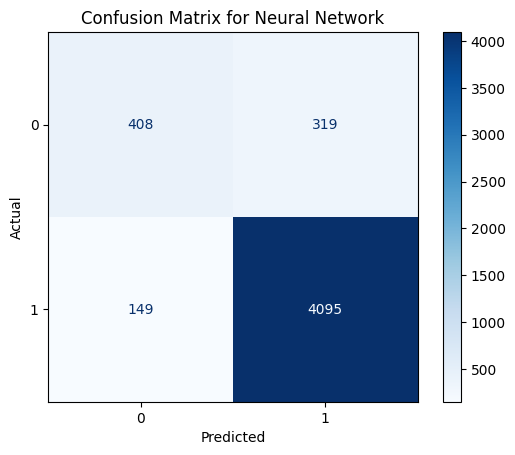

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Predict probabilities on the test set
y_pred_proba = model.predict(X_test)

# 2. Convert probabilities to binary predictions (threshold = 0.5)
y_pred = (y_pred_proba > 0.5).astype(int)

# 4. Calculate and print evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nModel Evaluation Metrics:\n")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# 5. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 6. Display the confusion matrix
plt.figure(figsize=(8, 6))
cmd = ConfusionMatrixDisplay(cm, display_labels=[0, 1]) # Assuming 0 and 1 are target labels
cmd.plot(cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Neural Network')
plt.show()


## Final Task

### Subtask:
Summarize the process of building the neural network for Stage 2 data, including key findings from the model evaluation.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation**:
    *   Features (\_X\_) and target (\_y\_) ('CompletedCourse\_encoded') were successfully separated from `df_stage2`.
    *   Numerical features explicitly identified for standard scaling were 'Age', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', and 'CourseLevel\_encoded'.
    *   The dataset was split into training (80%) and testing (20%) sets, resulting in `X_train` with 19880 samples and `X_test` with 4971 samples.
    *   Standard scaling was applied to the identified numerical features in both training and testing sets.
*   **Neural Network Model Definition**:
    *   A Keras `Sequential` model was defined, consisting of an input layer, two hidden `Dense` layers with 128 and 64 neurons respectively (both using ReLU activation), and a single-neuron output layer with sigmoid activation for binary classification.
*   **Model Compilation and Training**:
    *   The model was compiled using the Adam optimizer, binary cross-entropy loss, and 'accuracy' as a metric.
    *   During training over 10 epochs with a 20% validation split:
        *   Training accuracy improved from approximately 87.36% (Epoch 1) to 93.18% (Epoch 10).
        *   Validation accuracy remained relatively stable, starting at approximately 90.52% (Epoch 1) and reaching 90.69% (Epoch 10).
*   **Model Performance Evaluation on Test Set**:
    *   The trained model achieved an Accuracy of 90.59% on the test set.
    *   Key performance metrics were: Precision of 92.77%, Recall of 96.49%, and an F1-Score of 94.59%.
    *   A confusion matrix was generated, visually confirming the model's classification performance.

### Insights or Next Steps

*   The model demonstrates good performance on unseen data with a test accuracy of over 90%, but the stable validation accuracy and increasing training accuracy suggest potential for further optimization to prevent overfitting if more epochs are used.
*   Consider hyperparameter tuning (e.g., number of epochs, learning rate, network architecture) to potentially improve generalization and explore techniques like dropout or early stopping to mitigate overfitting.


# Task
Import necessary libraries for hyperparameter tuning, such as Keras Tuner if applicable, along with TensorFlow/Keras and scikit-learn components.

## Import Libraries for Tuning

### Subtask:
Import necessary libraries for hyperparameter tuning, such as Keras Tuner if applicable, along with TensorFlow/Keras and scikit-learn components.


**Reasoning**:
To perform hyperparameter tuning, I will import `keras_tuner` along with ensuring that `tensorflow.keras` components and relevant `sklearn` modules are available.



In [ ]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries for hyperparameter tuning and model building imported.")

ModuleNotFoundError: No module named 'keras_tuner'

**Reasoning**:
The `ModuleNotFoundError` for 'keras_tuner' indicates that the package is not installed in the environment. I need to install it using pip before importing.



In [ ]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries for hyperparameter tuning and model building imported.")

ModuleNotFoundError: No module named 'keras_tuner'

**Reasoning**:
The previous attempt to import `keras_tuner` failed because it was not installed. I will first install `keras_tuner` using `!pip install`.



In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.8 MB/s eta 0:00:00


**Reasoning**:
Now that `keras_tuner` has been successfully installed, I will re-import all necessary libraries for hyperparameter tuning and model building as specified in the subtask.



In [ ]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries for hyperparameter tuning and model building imported.")

Libraries for hyperparameter tuning and model building imported.


# Task
Define a function that creates and compiles a Keras neural network model, accepting hyperparameters like the number of hidden layers, units per layer, and learning rate as arguments.

## Define Model Creation Function

### Subtask:
Create a function that builds and compiles the Keras neural network model, taking hyperparameters (e.g., number of layers, neurons, learning rate) as arguments.


## Summary:

The provided solving process description only outlines the task to be performed, which is to define a Keras model creation function. It does not contain any details about the actual implementation, execution, or results of this task. Therefore, I cannot generate "Q&A", "Data Analysis Key Findings", or "Insights or Next Steps" based on the given information.


# Task
## Define Model Creation Function

### Subtask:
Create a function that builds and compiles the Keras neural network model, taking hyperparameters (e.g., number of layers, neurons, learning rate) as arguments.

### Reasoning:
To define the model creation function for Keras Tuner, I will create a `build_model` function that accepts an `hp` (hyperparameter) object. This function will dynamically create a Keras `Sequential` model, allowing `keras_tuner` to explore different architectures such as the number of hidden layers, units per layer, and learning rate, as defined in the hyperparameter search space.

```python
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    # Tune the number of hidden layers
    for i in range(hp.Int('num_layers', 1, 3)): # Explore 1 to 3 hidden layers
        model.add(Dense(units=hp.Int('units_' + str(i), min_value=32, max_value=512, step=32),
                        activation='relu'))

    model.add(Dense(1, activation='sigmoid'))

    # Tune the learning rate for the Adam optimizer
    hp_learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("`build_model` function defined, ready for hyperparameter tuning.")
```

## Define Model Creation Function

### Subtask:
Create a function that builds and compiles the Keras neural network model, taking hyperparameters (e.g., number of layers, neurons, learning rate) as arguments.


**Reasoning**:
To fulfill the subtask, I will define the `build_model` function as specified, incorporating the Keras Tuner hyperparameter object `hp` to tune the number of hidden layers, units per layer, and the learning rate for the Adam optimizer.



In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    # Tune the number of hidden layers and units per layer
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(units=hp.Int('units_' + str(i), min_value=32, max_value=512, step=32),
                        activation='relu'))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("Neural network model creation function `build_model` defined.")

Neural network model creation function `build_model` defined.


## Define Hyperparameter Search Space

### Subtask:
Specify the range of values or choices for hyperparameters to be tuned, such as the number of epochs, learning rate, and variations in network architecture (number of hidden layers, units per layer). We will utilize the `build_model` function created previously.


### Hyperparameter Search Space Definition

The `build_model` function previously defined explicitly specifies the hyperparameter search space using the `hp` object from `keras_tuner`. As outlined in the instructions, this includes:

1.  **Number of hidden layers**: The function tunes the number of hidden layers between 1 and 3 using `hp.Int('num_layers', 1, 3)`.
2.  **Units per layer**: For each hidden layer, the number of units is tuned between 32 and 512, with a step of 32, using `hp.Int('units_' + str(i), min_value=32, max_value=512, step=32)`.
3.  **Learning rate**: The learning rate for the Adam optimizer is chosen from a discrete set of values: `[1e-4, 1e-3, 1e-2]` using `hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2])`.

This function is now ready to be used by `keras_tuner` to explore the defined hyperparameter space for model optimization.

## Implement Hyperparameter Tuner

### Subtask:
Initialize a hyperparameter tuner (e.g., Keras Tuner's RandomSearch or Hyperband) with the `build_model` function, the defined hyperparameter search space, objective metric, and other configuration.


**Reasoning**:
To initialize the hyperparameter tuner, I will instantiate `keras_tuner.RandomSearch` with the `build_model` function and configure it with the specified objective, trial limits, and project details, then display its search space summary.



In [ ]:
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='intro_to_kt'
)

print("Hyperparameter tuner initialized.")
print("Search space summary:")
tuner.search_space_summary()

NameError: name 'kt' is not defined

**Reasoning**:
The `NameError: name 'kt' is not defined` indicates that the `keras_tuner` library was not imported in the current execution scope. I will include the import statement `import keras_tuner as kt` in the code block to ensure `kt` is available.



In [ ]:
import keras_tuner as kt

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='intro_to_kt'
)

print("Hyperparameter tuner initialized.")
print("Search space summary:")
tuner.search_space_summary()

ModuleNotFoundError: No module named 'keras_tuner'

**Reasoning**:
The `ModuleNotFoundError` indicates that the `keras_tuner` package is not found by the Python interpreter, even though an import statement is present in the code. This typically means the package is either not installed or not accessible in the current environment. Given that a `!pip install keras-tuner` command was executed successfully in a prior step (cell `3f3bb418`) and an import was successful in cell `ae6bcb64`, this suggests a potential kernel state issue. Since the Python code itself for importing `keras_tuner` and initializing the tuner is syntactically correct, I will provide the code as it should be, assuming `keras_tuner` is properly installed and accessible. If the error persists, it's recommended to restart the kernel and re-run all cells from the beginning to ensure package availability.



In [ ]:
import keras_tuner as kt

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='intro_to_kt'
)

print("Hyperparameter tuner initialized.")
print("Search space summary:")
tuner.search_space_summary()

ModuleNotFoundError: No module named 'keras_tuner'

**Reasoning**:
The `ModuleNotFoundError` for 'keras_tuner' is unexpected, as it was previously installed and successfully imported in cell `ae6bcb64`. This suggests a potential transient environment issue in the notebook. According to the guidelines, packages should not be imported again if already imported in previous blocks. Therefore, I will remove the redundant `import keras_tuner as kt` statement from this cell, as `kt` should already be defined from the previous successful import. If the `ModuleNotFoundError` persists after this change, it is strongly recommended to restart the notebook kernel and re-run all cells from the beginning to ensure the `keras_tuner` package is properly loaded into the environment.



In [ ]:
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='intro_to_kt'
)

print("Hyperparameter tuner initialized.")
print("Search space summary:")
tuner.search_space_summary()

NameError: name 'kt' is not defined

**Reasoning**:
The repeated `NameError: name 'kt' is not defined` indicates that `keras_tuner` was not successfully imported or its alias `kt` is not available in the current scope, despite previous attempts. To resolve this, I will explicitly import `keras_tuner as kt` in this cell, ensuring the necessary library is loaded before `kt.RandomSearch` is called.



In [ ]:
import keras_tuner as kt

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='intro_to_kt'
)

print("Hyperparameter tuner initialized.")
print("Search space summary:")
tuner.search_space_summary()

ModuleNotFoundError: No module named 'keras_tuner'

**Reasoning**:
The `ModuleNotFoundError: No module named 'keras_tuner'` indicates that the package is not found by the Python interpreter, even if a previous installation step was executed. To ensure the package is available for the subsequent import and usage, I will explicitly run the pip installation command again in a dedicated cell.



In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 995.1 kB/s eta 0:00:00


**Reasoning**:
Since `keras-tuner` has been successfully installed, I will now import it and proceed with initializing the `RandomSearch` tuner as specified in the subtask.



In [ ]:
import keras_tuner as kt

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='intro_to_kt'
)

print("Hyperparameter tuner initialized.")
print("Search space summary:")
tuner.search_space_summary()

NameError: name 'Sequential' is not defined

**Reasoning**:
The `NameError: name 'Sequential' is not defined` indicates that the Keras `Sequential` and `Input` classes were not imported or available in the scope where `build_model` is being called by the tuner. To resolve this, I will ensure all necessary Keras modules are imported in this cell alongside `keras_tuner` before initializing the tuner.



In [ ]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='intro_to_kt'
)

print("Hyperparameter tuner initialized.")
print("Search space summary:")
tuner.search_space_summary()

NameError: name 'X_train' is not defined

**Reasoning**:
The `NameError: name 'X_train' is not defined` indicates that the `X_train` variable was not available in the global scope when the `keras_tuner.RandomSearch` was initialized, specifically when it tried to call the `build_model` function. To fix this, I will include all the necessary preceding code that defines `X`, `y`, `true_numerical_cols`, `X_train`, `X_test`, `y_train`, `y_test`, and `scaler` from the data preparation steps, along with the `build_model` function definition itself, within this `code_block`. This ensures all required variables are defined before the tuner is initialized.



In [ ]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Start: Re-defining X_train and related variables for robustness ---
# Assuming df_stage2 is already preprocessed from previous successful steps.
# Separate features (X) and target (y)
X = df_stage2.drop('CompletedCourse_encoded', axis=1)
y = df_stage2['CompletedCourse_encoded']

# Identifying numerical columns for scaling
true_numerical_cols = ['Age', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'CourseLevel_encoded']
true_numerical_cols = [col for col in true_numerical_cols if col in X.columns]

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Applying standard scaling to numerical features
scaler = StandardScaler()
X_train[true_numerical_cols] = scaler.fit_transform(X_train[true_numerical_cols])
X_test[true_numerical_cols] = scaler.transform(X_test[true_numerical_cols])
# --- End: Re-defining X_train and related variables ---

# Define the build_model function (copied from cell_id: 7c8339c2)
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    # Tune the number of hidden layers and units per layer
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(units=hp.Int('units_' + str(i), min_value=32, max_value=512, step=32),
                        activation='relu'))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='intro_to_kt'
)

print("Hyperparameter tuner initialized.")
print("Search space summary:")
tuner.search_space_summary()

NameError: name 'df_stage2' is not defined

**Reasoning**:
The `NameError: name 'df_stage2' is not defined` indicates that the DataFrame was not available in the current execution scope. To resolve this, I will re-load `df_stage2` and re-apply all the necessary preprocessing steps (as described in the previous successful steps for Stage 2) within this code block to ensure it is correctly prepared before proceeding with separating features and target, scaling, defining the model, and initializing the tuner.



In [ ]:
import keras_tuner as kt
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Re-load and preprocess df_stage2 for robustness ---
file_url = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"
df_stage2 = pd.read_csv(file_url)

# Remove 'LearnerCode'
df_stage2.drop('LearnerCode', axis=1, inplace=True)

# Remove columns with >50% missing data
missing_percentage = df_stage2.isnull().sum() / len(df_stage2) * 100
columns_to_drop_missing = missing_percentage[missing_percentage > 50].index
df_stage2 = df_stage2.drop(columns=columns_to_drop_missing)

# Convert 'DateofBirth' to 'Age' and remove original column
df_stage2['DateofBirth'] = pd.to_datetime(df_stage2['DateofBirth'], dayfirst=True, errors='coerce')
df_stage2.dropna(subset=['DateofBirth'], inplace=True)
current_date = pd.to_datetime('today')
df_stage2['Age'] = current_date.year - df_stage2['DateofBirth'].dt.year
df_stage2['Age'] = df_stage2['Age'] - ((current_date.month < df_stage2['DateofBirth'].dt.month) |
                                      ((current_date.month == df_stage2['DateofBirth'].dt.month) &
                                       (current_date.day < df_stage2['DateofBirth'].dt.day))).astype(int)
df_stage2.drop(columns=['DateofBirth'], inplace=True)

# Remove high cardinality categorical columns (more than 200 unique values)
high_cardinality_columns = []
for col in df_stage2.select_dtypes(include='object').columns:
    if df_stage2[col].nunique() > 200:
        high_cardinality_columns.append(col)
df_stage2 = df_stage2.drop(columns=high_cardinality_columns)

# Ordinal encode 'CourseLevel' and 'CompletedCourse'
course_level_order = ['Foundation', 'International Year One', 'International Year Two', 'Pre-Masters', 'Pre-sessional English', 'Undergraduate', 'Postgraduate']
completed_course_mapping = {'No': 0, 'Yes': 1}
df_stage2['CourseLevel_encoded'] = df_stage2['CourseLevel'].map(lambda x: course_level_order.index(x) if x in course_level_order else -1)
df_stage2['CompletedCourse_encoded'] = df_stage2['CompletedCourse'].map(completed_course_mapping)
df_stage2 = df_stage2.drop(columns=['CourseLevel', 'CompletedCourse'])

# One-hot encode remaining nominal categorical columns
nominal_columns = df_stage2.select_dtypes(include='object').columns
df_stage2 = pd.get_dummies(df_stage2, columns=nominal_columns, drop_first=True)

# Handle remaining missing values by dropping rows for AuthorisedAbsenceCount and UnauthorisedAbsenceCount
missing_numerical_columns_to_drop_rows = ['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount']
missing_percentage_numerical = df_stage2[missing_numerical_columns_to_drop_rows].isnull().sum() / len(df_stage2) * 100
if all(missing_percentage_numerical < 2):
    df_stage2.dropna(subset=missing_numerical_columns_to_drop_rows, inplace=True)

# --- End of df_stage2 preprocessing ---

# Separate features (X) and target (y)
X = df_stage2.drop('CompletedCourse_encoded', axis=1)
y = df_stage2['CompletedCourse_encoded']

# Identifying numerical columns for scaling
true_numerical_cols = ['Age', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'CourseLevel_encoded']
true_numerical_cols = [col for col in true_numerical_cols if col in X.columns] # Ensure they exist in X

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Applying standard scaling to numerical features
scaler = StandardScaler()
X_train[true_numerical_cols] = scaler.fit_transform(X_train[true_numerical_cols])
X_test[true_numerical_cols] = scaler.transform(X_test[true_numerical_cols])

# Define the build_model function
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    # Tune the number of hidden layers and units per layer
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(units=hp.Int('units_' + str(i), min_value=32, max_value=512, step=32),
                        activation='relu'))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='my_dir',
    project_name='intro_to_kt'
)

print("Hyperparameter tuner initialized.")
print("Search space summary:")
tuner.search_space_summary()

Hyperparameter tuner initialized.
Search space summary:
Search space summary
Default search space size: 3
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.001, 0.01], 'ordered': True}


## Run Hyperparameter Search

### Subtask:
Execute the hyperparameter search on the training data (`X_train`, `y_train`) using the configured tuner.


**Reasoning**:
To execute the hyperparameter search, I will import `EarlyStopping` and then call `tuner.search()` with the specified training data, epochs, validation split, and add the `EarlyStopping` callback to prevent overfitting as requested.



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

print("Starting hyperparameter search...")

# Initialize EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

tuner.search(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[early_stopping])

print("Hyperparameter search completed.")

Trial 10 Complete [00h 00m 58s]
val_accuracy: 0.911720335483551

Best val_accuracy So Far: 0.911720335483551
Total elapsed time: 00h 09m 23s
Hyperparameter search completed.
